# 16 · Capability requirements: sizing the powertrain to what the aircraft must be able to do

A sizing code distinguishes **capability requirements** (hover at this altitude, fly this fast, climb this well, reach this ceiling, survive this
failure), each a single operating point at maximum weight, from the **mission** (what is flown, which burns fuel and battery energy). This
notebook covers the first: `requirements/capability.py` (84 lines) turns requirements into flight conditions, and
`examples/requirements_sizing.py` sizes the powertrain ratings so every requirement point has non-negative margins, inside the mass closure.
It is the fourth rung of the ladder: closure + trim + four flight points + rubber powertrain ratings as design variables.

**In this notebook**
1. Requirements as flight conditions, and the turbine-only rule for sustained capability.
2. Design variables for a rubber powertrain: `SeriesHybridSizing` and `build_series_hybrid_from_sizing`.
3. The sizing problem, line by line.
4. What sizes what: binding margins by component.
5. What each requirement costs: multipliers and re-solves.
6. The Halo's requirement set.

**Run time:** a few seconds.

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect
from dataclasses import replace, fields
from aircraft_closure.requirements.capability import (RequirementSet, HoverRequirement, ClimbRequirement, SpeedRequirement,
                                                      CeilingRequirement)
from aircraft_closure.powertrain.topologies import SeriesHybridSizing, build_series_hybrid_from_sizing
from aircraft_closure.performance.flight_point import build_flight_point
from aircraft_closure.core.margins import margin_report

## 1. Requirements as flight conditions

Each requirement class has a `flight_condition()` method. A requirement is met when every operating margin at its point is non-negative.
Sustained requirements (climb, speed, ceiling) default to `hybridization_electric = 0`: they must hold on turbogenerator power alone, since the
battery would run out. Hover may draw on the battery (`None`, a free split).

In [2]:
requirements = RequirementSet()
for condition in requirements.flight_conditions():
    print(f"{condition.label:<10} mode {condition.mode:<9} V {condition.velocity_m_s:5.1f} m/s  h {condition.altitude_m:6.0f} m  "
          f"climb {condition.climb_rate_m_s:3.1f} m/s  T/W {condition.thrust_to_weight}  battery share {condition.hybridization_electric}")

hover      mode hover     V   0.0 m/s  h   1000 m  climb 0.0 m/s  T/W 1.1  battery share None
climb      mode airplane  V  50.0 m/s  h   1000 m  climb 5.0 m/s  T/W 1.0  battery share 0.0
max_speed  mode airplane  V  80.0 m/s  h   1000 m  climb 0.0 m/s  T/W 1.0  battery share 0.0
ceiling    mode airplane  V  55.0 m/s  h   4000 m  climb 0.5 m/s  T/W 1.0  battery share 0.0


## 2. A rubber powertrain as design variables

`SeriesHybridSizing` collects every rating that can be sized: motor and generator peak-efficiency torques (McDonald rubber machines, tutorial 05),
turboshaft rating, battery discharge power and energy, rotor disk area. Every field may be an Opti variable. `build_series_hybrid_from_sizing`
turns it into components and a topology (tutorial 11): the gearbox is rated to the motor, the rotor to the gearbox output, the battery is reference
packs in parallel (resistance falls as capacity grows), rotor mass scales with disk area.

In [3]:
print(inspect.getsource(build_series_hybrid_from_sizing))

def build_series_hybrid_from_sizing(sizing):
    ratios = dict(torque_ratio=2.5, power_ratio=1.25, speed_ratio=2.5)
    motor = rubber_machine(Motor, sizing.speed_peak_motor_rad_s, sizing.torque_peak_motor_Nm, **ratios)
    generator = rubber_machine(Generator, sizing.speed_peak_generator_rad_s, sizing.torque_peak_generator_Nm, **ratios)
    gearbox = Gearbox(reduction_ratio=sizing.reduction_ratio, power_rated_W=motor.power_rated_W)
    propulsor = ActuatorDiskPropulsor(area_disk_m2=sizing.area_disk_m2,
                                      mass_kg=sizing.mass_per_disk_area_kg_m2 * sizing.area_disk_m2,
                                      max_shaft_power_W=gearbox.power_rated_W * gearbox.efficiency)
    battery = Battery(energy_capacity_J=sizing.energy_capacity_battery_J,
                      resistance_ohm=sizing.resistance_energy_product_ohm_J / sizing.energy_capacity_battery_J,
                      max_discharge_power_W=sizing.power_max_discharge_battery_W,
                      

## 3. The sizing problem

`solve_requirements_sizing`, written out. Design variables: take-off mass, wing position, five ratings and disk area (battery energy is held: no
mission yet). Constraints: closure, hover pitch trim, and every margin at every requirement point ≥ 0. Objective: take-off mass.

In [4]:
from examples.aircraft_mass_closure import build_reference_aircraft
from examples.requirements_sizing import build_sizing_variables, area_disk_max_m2
from aircraft_closure.aerodynamics.simple import SimpleAerodynamics
from aircraft_closure.vehicle.condition import StructuralDesignCondition

def size_to_requirements(requirements=RequirementSet(), keep=False):
    aerodynamics = SimpleAerodynamics()
    opti = asb.Opti()
    mass_takeoff_kg = opti.variable(init_guess=1550, lower_bound=100)
    x_le_wing_m = opti.variable(init_guess=3.2, lower_bound=0.5, upper_bound=5.5)
    sizing = build_sizing_variables(opti)                                   # the five ratings and the disk area
    topology = build_series_hybrid_from_sizing(sizing)
    aircraft = build_reference_aircraft(x_le_wing_m, requirements.mass_payload_kg, sizing.count_rotors,
                                        area_horizontal_tail_m2=2.16, area_vertical_tail_m2=1.92, topology=topology)
    total = aircraft.get_mass_breakdown(StructuralDesignCondition(mass_design_kg=mass_takeoff_kg)).total()
    points = [build_flight_point(opti, aircraft, aerodynamics, c, mass_takeoff_kg) for c in requirements.flight_conditions()]
    margins = tuple(m for point in points for m in point.margins)
    opti.subject_to([mass_takeoff_kg == total.mass,
                     total.x_cg == x_le_wing_m + 0.25 * aircraft.wing.chord_root_m()])
    duals = [opti.subject_to(m.value >= 0) for m in margins]                 # one dual per margin, kept for section 5
    opti.minimize(mass_takeoff_kg / 1000)
    solution = opti.solve(verbose=False)
    return dict(opti=opti, solution=solution, mass_takeoff_kg=mass_takeoff_kg, sizing=sizing, topology=topology, points=points,
                margins=margins, duals=duals, aircraft=aircraft)

run = size_to_requirements()
s = run["solution"]
print(f"MTOM {s.value(run['mass_takeoff_kg']):,.1f} kg in {s.stats()['iter_count']} iterations; problem size {describe_opti(run['opti'])}")
instances = run["topology"].instances
print(f"motor {s.value(instances['motor'].component.power_rated_W) / 1e3:.1f} kW x4, generator {s.value(instances['generator'].component.power_rated_W) / 1e3:.1f} kW, "
      f"turboshaft {s.value(run['sizing'].power_rated_turboshaft_W) / 1e3:.1f} kW, battery {s.value(run['sizing'].power_max_discharge_battery_W) / 1e3:.1f} kW, "
      f"disk {s.value(run['sizing'].area_disk_m2):.2f} m2 (max {area_disk_max_m2})")
from examples.requirements_sizing import solve_requirements_sizing
check("reproduces examples/requirements_sizing.py", abs(solve_requirements_sizing().mass_takeoff_kg - s.value(run["mass_takeoff_kg"])) < 1e-6)

MTOM 1,113.4 kg in 22 iterations; problem size {'variables': 23, 'constraints': 101, 'equalities': 13, 'inequalities': 88}
motor 73.2 kW x4, generator 200.3 kW, turboshaft 200.3 kW, battery 279.5 kW, disk 3.77 m2 (max 15.0)


PASS  reproduces examples/requirements_sizing.py


## 4. What sizes what

Group the binding margins by component. Each sized rating should be pinned by at least one requirement; otherwise the optimizer would shrink it.

In [5]:
binding = [e for e in margin_report(run["margins"], s.value) if abs(e.value) < 1e-5]
by_component = {}
for entry in binding:
    point, _, rest = entry.label.partition(": ")
    component = rest.split(" ")[0]
    by_component.setdefault(component, []).append(f"{point} ({rest.split(' ', 1)[1]})")
for component, reasons in by_component.items():
    print(f"{component:<12} sized by: {', '.join(reasons)}")
print(f"\nhover battery share {s.value(run['points'][0].hybridization_electric):.3f}; disk area "
      f"{s.value(run['sizing'].area_disk_m2):.2f} m2 (bound {area_disk_max_m2} m2)")

turboshaft   sized by: max_speed (power_shaft_W)
generator    sized by: max_speed (power_shaft_W)
motor        sized by: hover (power_shaft_W)
gearbox      sized by: hover (power_input_W)
propulsor    sized by: hover (power_shaft_W)

hover battery share 0.480; disk area 3.77 m2 (bound 15.0 m2)


The hover (thrust-heavy, battery allowed) sizes the motor, gearbox and rotor; the speed point (turbine power only, high drag) sizes the turboshaft
and generator. Climb and ceiling are slack: at this design point the 80 m/s speed requirement already demands more turbine power.

The disk area is *not* at its 15 m² bound. It settles where the rotor mass (3 kg/m² × 4 rotors) balances the motor and gearbox mass that a lighter
disk loading would save. The battery's mass is set by its fixed energy, so lower hover power saves no battery mass here. In the Halo, with the AFDD
rotor weights and a battery sized by power, the trade goes the other way and the rotor radius sits on its span-clearance limit (tutorial 00's
`rotor_radius_m`). The same equations give different active sets on different aircraft; read the binding list, don't assume it.

## 5. What each requirement costs

Every margin's multiplier is d(MTOM in tonnes)/d(margin). Sum them by requirement point to see which requirements are expensive, then check one
by re-solving with a tighter requirement:

In [6]:
cost = {}
for margin, dual in zip(run["margins"], run["duals"]):
    point = margin.label.partition(": ")[0]
    if dual is None:          # a margin with no variables in it (a constant) gets no constraint and no dual
        continue
    cost[point] = cost.get(point, 0.0) + float(s.value(dual))
for point, total_lambda in sorted(cost.items(), key=lambda item: -item[1]):
    print(f"{point:<10} sum of multipliers {total_lambda:7.4f} t per unit margin  (about {10 * total_lambda:5.1f} kg per 1 % on all its limits)")

faster = replace(requirements, speed=replace(requirements.speed, velocity_m_s=requirements.speed.velocity_m_s * 1.01))
run_faster = size_to_requirements(faster)
delta = run_faster["solution"].value(run_faster["mass_takeoff_kg"]) - s.value(run["mass_takeoff_kg"])
print(f"\nre-solve with 1 % more speed: MTOM +{delta:.2f} kg")
check("a faster requirement costs mass", delta > 0)

max_speed  sum of multipliers  0.2237 t per unit margin  (about   2.2 kg per 1 % on all its limits)
hover      sum of multipliers  0.1323 t per unit margin  (about   1.3 kg per 1 % on all its limits)
climb      sum of multipliers  0.0000 t per unit margin  (about   0.0 kg per 1 % on all its limits)
ceiling    sum of multipliers  0.0000 t per unit margin  (about   0.0 kg per 1 % on all its limits)



re-solve with 1 % more speed: MTOM +6.16 kg
PASS  a faster requirement costs mass


(A 1 % faster requirement is not the same as 1 % on every limit at the speed point: drag power grows roughly as $V^3$, so the cost is larger than
the multiplier sum suggests. The multipliers are local sensitivities to the margins as written.)

A sweep of the hover altitude shows a requirement curve:

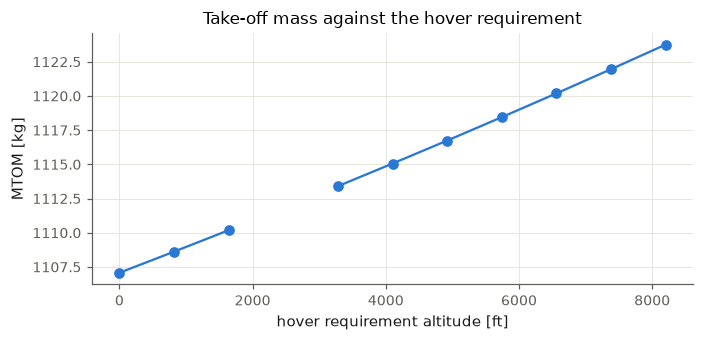

In [7]:
altitudes_m = onp.linspace(0, 2500, 11)
masses = []
for altitude_m in altitudes_m:
    r = replace(requirements, hover=replace(requirements.hover, altitude_m=altitude_m))
    try:
        run_r = size_to_requirements(r)
        masses.append(run_r["solution"].value(run_r["mass_takeoff_kg"]))
    except RuntimeError:
        masses.append(onp.nan)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(altitudes_m / u.foot, masses, "o-", color=blue)
ax.set(xlabel="hover requirement altitude [ft]", ylabel="MTOM [kg]", title="Take-off mass against the hover requirement")
plt.tight_layout(); plt.show()

Two things to notice. Mass grows almost linearly with the hover altitude here (denser-to-thinner air raises hover power, which the
motors, gearboxes and battery power must cover). And **one point is missing**: at about 2,500 ft the solve failed from the default initial guess.
That is a local-convergence failure, not an infeasibility, since the neighbours on either side solve. It is the everyday reality of
gradient-based sizing and the reason the Halo driver has an explicit starting-point strategy and warm starts from neighbouring designs
(tutorial 20).

## 6. The Halo's requirement set

`HaloRequirements` holds the Halo's requirements as plain fields and maps the capability ones onto a `RequirementSet`. The Halo adds points this
generic set does not have: failure hovers (engine out, lane out, bus out, string out), a hot-day hover at the destination at end-of-mission mass and
SOC, a stall-speed limit, and a mission (tutorial 17).

In [8]:
from examples.halo_sizing import HaloRequirements
halo = HaloRequirements()
for f in fields(HaloRequirements):
    print(f"{f.name:<30} {getattr(halo, f.name)}")
print()
for condition in halo.requirement_set().flight_conditions():
    print(f"{condition.label:<10} V {condition.velocity_m_s / u.knot:5.0f} kt, {condition.altitude_m / u.foot:7,.0f} ft, battery share {condition.hybridization_electric}")

mass_payload_kg                900.0
range_m                        824140.0
altitude_cruise_m              3047.9999999999995
velocity_max_m_s               108.03333333333335
altitude_hover_m               1219.1999999999998
thrust_to_weight_hover         1.05
altitude_ceiling_m             3962.3999999999996
climb_rate_ceiling_m_s         0.5
climb_rate_m_s                 7.5
velocity_climb_m_s             80.0
velocity_stall_max_m_s         61.733333333333334
cl_max                         1.5
duration_loiter_s              1200.0
duration_hover_s               60.0
duration_engine_out_hover_s    60.0
hover_hot_day                  True
altitude_hover_hot_m           1219.1999999999998
temperature_hover_hot_K        308.15
thrust_to_weight_hover_hot     1.05
duration_hover_hot_s           60.0

hover      V     0 kt,   4,000 ft, battery share None
climb      V   156 kt,   3,281 ft, battery share 0.0
max_speed  V   210 kt,  10,000 ft, battery share 0.0
ceiling    V   156 kt,  13,00

## Summary

- Capability requirements are single flight points at maximum weight; sustained ones run on turbine power alone.
- The rubber powertrain's ratings are design variables; every requirement point's margins are constraints; mass closes; MTOM is minimized.
- Binding margins say which requirement sizes which component; multipliers say how much each requirement costs.
- Whether a geometric limit (disk area, rotor radius) binds depends on what the hover power is traded against; read the binding list.

## Check yourself

<details><summary>1. Why must every sized rating have at least one binding margin?</summary>

Mass grows with every rating, so the optimizer shrinks each rating until something stops it. If nothing did, the rating would hit its lower bound (a sign the variable is irrelevant or a requirement is missing).
</details>

<details><summary>2. The battery's energy is fixed here. Which constraint would size it?</summary>

An energy requirement: a mission's SOC chain (tutorial 17) or a reserve such as the engine-out hover from the reserve SOC (tutorial 18).
</details>

In [9]:
check_summary()

2 of 2 checks passed
